## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import random

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
augmentation = False
augmentation_weights = [0.9, 0.1]
proportion_of_augmented = 0.25
remove_outliers = True

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) PCA
7) sieć neuronowa
8) przedziały ufności / kostka wielowymiarowa i szukanie najbliższego sąsiada

## Loading the data

In [3]:
data_path = '../data/DANE.xlsx'
figures_path = '../results/visualisations/'

In [4]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [5]:
inks_df = inks_df.reset_index(drop=False)

In [6]:
inds_df = inds_df.reset_index(drop=False)

In [7]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [8]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [9]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

### Removing some data

1. Let's remove rows with missing values.

In [10]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [11]:
inDKs_df.dropna(inplace=True)

2. Let's keep only columns that we need.

In [12]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

If you want to use version with 29 numbers, just comment out the cell below.

In [13]:
inks_colnames = [
 'Al_inks',
 'S_inks',
 'Cr_inks',
 'Mn_inks',
 'Co_inks',
 'Cu_inks',
 'Zn_inks',
 'Pb_inks']

inds_colnames = [
 'Al_inds',
 'S_inds',
 'Cr_inds',
 'Mn_inds',
 'Co_inds',
 'Cu_inds',
 'Zn_inds',
 'Pb_inds']

In [14]:
inDKs_df = inDKs_df[inks_colnames + inds_colnames + ['Sample_id']]

### Removing ouliers

In [15]:
#plt.hist(inDKs_df['Pb_inks'], bins=100)

In [16]:
# inDKs_df['Al_inds']..nlargest50)
# inDKs_df['Al_inks']..nlargest(30)

# inDKs_df['S_inds'].nlargest(5) #165
# inDKs_df['S_inks'].nlargest(20)

# inDKs_df['Cr_inds'].nlargest(50)
# inDKs_df['Cr_inks'].nlargest(5)

# inDKs_df['Mn_inds'].nlargest(20)
# inDKs_df['Mn_inks'].nlargest(20)

# inDKs_df['Co_inds'].nlargest(20)
# inDKs_df['Co_inks'].nlargest(20) #104, 103

# inDKs_df['Cu_inds'].nlargest(50) #2381, 2384, 2382, 2375, 2383, 2376, 2378, 2380, 2373, 2379, 2372, 2374, 2371, 2377, 2370
# inDKs_df['Cu_inks'].nlargest(20) #2374, 2377, 2376, 2372, 2375, 2371, 2373, 2370, 2379, 2378, 2380, 2381, 2383, 2382, 2384

# inDKs_df['Zn_inds'].nlargest(20) #165, 896, 893, 892, 891, 897, 890, 894, 895, 899, 889, 888, 887, 886, 898, 885
# inDKs_df['Zn_inks'].nlargest(20) #104, 890, 891, 889, 895, 892, 888, 896, 894, 893, 897, 885, 887, 886, 898, 899

# inDKs_df['Pb_inds'].nlargest(20) #2128, 2129, 2127, 2126, 2125, 2124, 2123, 2122, 2120, 2121, 2119, 2118, 2117, 2115, 2116
# inDKs_df['Pb_inks'].nlargest(20) #2128, 2127, 2129, 2122, 2126, 2125, 2124, 2120, 2116, 2123, 2121, 2117, 2118, 2119, 2115

In [17]:
outliers_indices = [165, #S
                    104, 103 #Co
                    ] + \
                    list(range(2370, 2385)) + \
                    list(range(885, 900)) + \
                    list(range(2115, 2130)) #Cu, Zn, Pb

In [18]:
if remove_outliers:
    inDKs_df.drop(inDKs_df.index[outliers_indices], inplace=True)

Now we have Sample ids from 0 to 160, excluding 59, 141, 158.

### Train test split

In [19]:
if keep_sample_together:
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

In [20]:
# if augmentation:
#     X_train = torch.cat([X_train, X_aug])
#     y_train = torch.cat([y_train, y_aug])

### Data augmentation

In [21]:
if real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [22]:
if real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))
    
    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']
    
    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [23]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']
if augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[inds_colnames].values)
y_train = np.array(X_y_train[inks_colnames].values)
X_val = np.array(X_y_val[inds_colnames].values)
y_val = np.array(X_y_val[inks_colnames].values)
X_test = np.array(X_y_test[inds_colnames].values)
y_test = np.array(X_y_test[inks_colnames].values)
if augmentation:
    X_augmented = np.array(X_y_augmented[inds_colnames].values)
    y_augmented = np.array(X_y_augmented[inks_colnames].values)

### Normalization

In [24]:
if augmentation:
    X_all = np.concatenate([X_train, X_augmented])
    y_all = np.concatenate([y_train, y_augmented])
    
    X_all = (X_all - np.mean(X_all, axis=0))/np.std(X_all, axis=0)
    y_all = (y_all - np.mean(y_all, axis=0))/np.std(y_all, axis=0)
        
    X_train = X_all[:X_train.shape[0],:]
    X_augmented = X_all[X_train.shape[0]:,:]
    y_train = y_all[:y_train.shape[0],:]
    y_augmented = y_all[y_train.shape[0]:,:]
else:
    X_train = (X_train - np.mean(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.mean(y_train, axis=0))/np.std(y_train, axis=0)
    
X_val = (X_val - np.mean(X_val, axis=0))/np.std(X_val, axis=0)
y_val = (y_val - np.mean(y_val, axis=0))/np.std(y_val, axis=0)

X_test = (X_test - np.mean(X_test, axis=0))/np.std(X_test, axis=0)
y_test = (y_test - np.mean(y_test, axis=0))/np.std(y_test, axis=0)

### PCA

In [25]:
n_components_x = 2
n_components_y = 2

pca_x = PCA(n_components=n_components_x)
X_train = pca_x.fit_transform(X_train)
X_val = pca_x.transform(X_val)
X_test = pca_x.transform(X_test)
if augmentation:
    X_augmented = pca_x.transform(X_augmented)

pca_y = PCA(n_components=n_components_y)
y_train = pca_y.fit_transform(y_train)
y_val = pca_y.transform(y_val)
y_test = pca_y.transform(y_test)
if augmentation:
    y_augmented = pca_y.transform(y_augmented)

### PCA visualisation

In [26]:
train_pca_df = pd.DataFrame(np.concatenate([X_train, y_train], axis=1), 
                            columns = ['X_PC_' + str(pc_nr) for pc_nr in range(1, n_components_x+1)]
                                    + ['y_PC_' + str(pc_nr) for pc_nr in range(1, n_components_y+1)])
train_pca_df['Sample_id'] = train_order

val_pca_df = pd.DataFrame(np.concatenate([X_val, y_val], axis=1), 
                            columns = ['X_PC_' + str(pc_nr) for pc_nr in range(1, n_components_x+1)]
                                    + ['y_PC_' + str(pc_nr) for pc_nr in range(1, n_components_y+1)])
val_pca_df['Sample_id'] = val_order

test_pca_df = pd.DataFrame(np.concatenate([X_test, y_test], axis=1), 
                            columns = ['X_PC_' + str(pc_nr) for pc_nr in range(1, n_components_x+1)]
                                    + ['y_PC_' + str(pc_nr) for pc_nr in range(1, n_components_y+1)])
test_pca_df['Sample_id'] = test_order

train_val_pca_df = pd.concat([train_pca_df, val_pca_df])

In [27]:
pc_names_x = ['X_PC_' + str(pc_nr) for pc_nr in range(1, n_components_x+1)]
pc_names_y = ['y_PC_' + str(pc_nr) for pc_nr in range(1, n_components_y+1)]

pc_names = pc_names_x + pc_names_y

In [28]:
mean_df = train_val_pca_df[['Sample_id']]

for name in pc_names:
    mean_df[name] = train_val_pca_df.groupby('Sample_id')[name].transform('mean')
mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_4752/2725509599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_pca_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_4752/2725509599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_pca_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_4752/2725509599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

In [29]:
closest_x = []
for i in range(train_val_pca_df.shape[0]):
    idx_min = abs(train_val_pca_df[pc_names_x].iloc[i] - mean_df[pc_names_x]).sum(1).idxmin()
    closest_x.append(int(mean_df.iloc[idx_min,:]['Sample_id']))
    
closest_y = []
for i in range(train_val_pca_df.shape[0]):
    idx_min = abs(train_val_pca_df[pc_names_y].iloc[i] - mean_df[pc_names_y]).sum(1).idxmin()
    closest_y.append(int(mean_df.iloc[idx_min,:]['Sample_id']))

In [30]:
train_val_pca_df['Closest_id_X'] = closest_x
train_val_pca_df['Closest_id_y'] = closest_y

In [31]:
train_val_pca_df[train_val_pca_df['Closest_id_y'] == train_val_pca_df['Sample_id']]

,X_PC_1,X_PC_2,y_PC_1,y_PC_2,Sample_id,Closest_id_X,Closest_id_y
0,-0.939508,-0.025984,-0.721336,-0.190248,115,32,115
2,5.993377,-1.183670,1.486295,3.176099,153,142,153
4,-0.518423,-0.155326,-0.580629,0.460170,155,155,155
5,-0.950233,-0.037950,0.000038,-0.263081,128,128,128
12,-0.695927,0.006522,-0.366001,1.034584,148,73,148
...,...,...,...,...,...,...,...
458,3.688394,-1.299530,0.539864,2.625306,146,88,146
459,-0.160464,-0.614769,-0.667644,-0.135539,27,27,27
460,-0.404271,-0.168740,1.541499,-0.646588,91,103,91
464,3.004875,-0.695672,0.269176,2.634662,146,38,146


In [32]:
(train_val_pca_df[train_val_pca_df['Closest_id_X'] == train_val_pca_df['Sample_id']]).shape[0] / train_val_pca_df.shape[0]

0.283148441627047

In [33]:
(train_val_pca_df[train_val_pca_df['Closest_id_y'] == train_val_pca_df['Sample_id']]).shape[0] / train_val_pca_df.shape[0]

0.37136819862651876

In [34]:
%matplotlib notebook

<IPython.core.display.Javascript object>


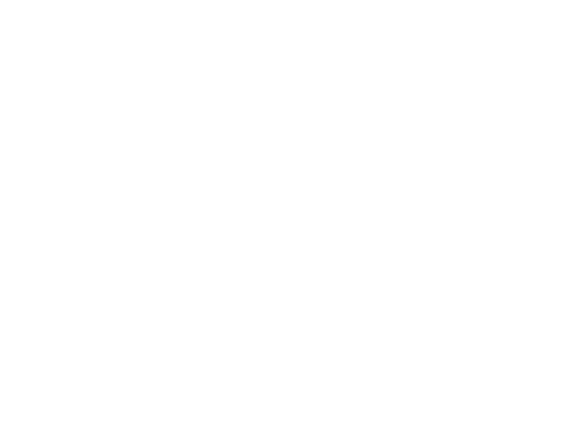

In [36]:
up_to = 10

# num_colors = up_to
# cm = plt.get_cmap('gist_rainbow')
# colors_list = [cm(1.*i/num_colors) for i in range(num_colors)]

# colors_vector = [list(colors_list[el]) for el in range(num_colors)]
# cm = plt.get_cmap('gist_rainbow')
# colors_list = [cm(1.*i/num_colors) for i in range(num_colors)]
# colors_vector = [list(colors_list[el]) for el in range(num_colors)]

colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
             '#7f7f7f', '#bcbd22', '#17becf']


X_or_y = 'y'
idxs_included_in_plot = list(mean_df['Sample_id'].unique())[:up_to]

for order, idx in enumerate(idxs_included_in_plot):
    filtered_train_val_pca_df = train_val_pca_df[train_val_pca_df['Sample_id'] == idx]
    plt.plot(filtered_train_val_pca_df[X_or_y + '_PC_1'], 
             filtered_train_val_pca_df[X_or_y + '_PC_2'], 
             '.', c=colors_list[order])
    
    filtered_mean_df = mean_df[mean_df['Sample_id'] == idx]
    plt.plot(filtered_mean_df[X_or_y + '_PC_1'], 
             filtered_mean_df[X_or_y + '_PC_2'],
             c=colors_list[order], marker='^', markersize=10)

### Converting to tensors

In [34]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [35]:
if augmentation:
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
else:
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [36]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [37]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [38]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [39]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [40]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
#         nn.Linear(input_size, input_size),
#         nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [41]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [42]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [43]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/2,1/2]).unsqueeze(1).to(device)

#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [44]:
# loss = F.l1_loss(torch.t(torch.mul(torch.t(forecast), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))) ,
#                          torch.t(torch.mul(torch.t(torch.tensor(target,dtype=torch.float).to(DEVICE)), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))),reduction='mean')
# loss.backward()
# params.append(net.parameters())
# optimiser.step()

In [45]:
EPOCHS = 3000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 0.4889264980951945 test 0.4887911685848538
EPOCH 2:
LOSS train 0.47834636171658834 test 0.48724291850871676
EPOCH 3:
LOSS train 0.47647300561269124 test 0.4857605719302274
EPOCH 4:
LOSS train 0.48929593960444134 test 0.48435166786240125
EPOCH 5:
LOSS train 0.4909152011076609 test 0.4830369901870876
EPOCH 6:
LOSS train 0.4839940349260966 test 0.48179605782409257
EPOCH 7:
LOSS train 0.48594838579495747 test 0.4805950899667378
EPOCH 8:
LOSS train 0.4858200331528982 test 0.4794704771054445
EPOCH 9:
LOSS train 0.47392183740933735 test 0.47841685519942756
EPOCH 10:
LOSS train 0.47663487990697223 test 0.4774031506749145
EPOCH 11:
LOSS train 0.47332945267359416 test 0.47639097160176386
EPOCH 12:
LOSS train 0.4829397857189178 test 0.47544899752622916
EPOCH 13:
LOSS train 0.47381542523701986 test 0.47453881620983535
EPOCH 14:
LOSS train 0.4651254137357076 test 0.4736744380764317
EPOCH 15:
LOSS train 0.4728095610936483 test 0.4728335176402003
EPOCH 16:
LOSS train 0.47653405865

LOSS train 0.4056953589121501 test 0.4184738374806406
EPOCH 130:
LOSS train 0.41085631450017296 test 0.41804696853716666
EPOCH 131:
LOSS train 0.4122152010599772 test 0.41761400580469066
EPOCH 132:
LOSS train 0.4077460547288259 test 0.4171988841004764
EPOCH 133:
LOSS train 0.4037861704826355 test 0.41678934615058233
EPOCH 134:
LOSS train 0.4123459319273631 test 0.416342396163362
EPOCH 135:
LOSS train 0.4056702395280202 test 0.41587002119560285
EPOCH 136:
LOSS train 0.40100340644518534 test 0.4154689493058603
EPOCH 137:
LOSS train 0.398631418744723 test 0.4150287097453568
EPOCH 138:
LOSS train 0.40937270820140836 test 0.41455305465163056
EPOCH 139:
LOSS train 0.40821219285329186 test 0.41414329390737076
EPOCH 140:
LOSS train 0.42165283958117167 test 0.41370576157977307
EPOCH 141:
LOSS train 0.39426013131936394 test 0.41328067373374344
EPOCH 142:
LOSS train 0.4066902836163839 test 0.41288338213341647
EPOCH 143:
LOSS train 0.4011101941267649 test 0.41248778483284176
EPOCH 144:
LOSS train 

LOSS train 0.36661452253659566 test 0.389529155166466
EPOCH 256:
LOSS train 0.37581920226415 test 0.38943310276868476
EPOCH 257:
LOSS train 0.3714854677518209 test 0.38930322722637956
EPOCH 258:
LOSS train 0.3743622620900472 test 0.38917804756182156
EPOCH 259:
LOSS train 0.3788361310958862 test 0.3890287549183841
EPOCH 260:
LOSS train 0.3683578610420227 test 0.3889032790146548
EPOCH 261:
LOSS train 0.37549615104993184 test 0.3887998420226423
EPOCH 262:
LOSS train 0.374030601978302 test 0.3886811322127842
EPOCH 263:
LOSS train 0.36297500332196553 test 0.3885361964849732
EPOCH 264:
LOSS train 0.3858904143174489 test 0.38845068159737167
EPOCH 265:
LOSS train 0.3651068975528081 test 0.3883361794636094
EPOCH 266:
LOSS train 0.37328055103619895 test 0.3882225296432585
EPOCH 267:
LOSS train 0.3645714282989502 test 0.38810828093140687
EPOCH 268:
LOSS train 0.3668934901555379 test 0.38798182195972036
EPOCH 269:
LOSS train 0.38657381137212116 test 0.38785829251231274
EPOCH 270:
LOSS train 0.3741

LOSS train 0.35656483968098956 test 0.3781537662264164
EPOCH 382:
LOSS train 0.3608108898003896 test 0.37805698881955335
EPOCH 383:
LOSS train 0.37199845115343727 test 0.3780247707407183
EPOCH 384:
LOSS train 0.3517814536889394 test 0.37793532497237753
EPOCH 385:
LOSS train 0.35624245802561444 test 0.37787152501412585
EPOCH 386:
LOSS train 0.3489648332198461 test 0.3778220513984875
EPOCH 387:
LOSS train 0.3573990861574809 test 0.37765170340642396
EPOCH 388:
LOSS train 0.356336639324824 test 0.3775513616905308
EPOCH 389:
LOSS train 0.35644586086273194 test 0.3775331415078811
EPOCH 390:
LOSS train 0.3564212183157603 test 0.3774639629456313
EPOCH 391:
LOSS train 0.3752789358297984 test 0.3773880968271177
EPOCH 392:
LOSS train 0.36472652554512025 test 0.37728360982981163
EPOCH 393:
LOSS train 0.3549846013387044 test 0.37719563347629353
EPOCH 394:
LOSS train 0.35886102517445884 test 0.37715073282740036
EPOCH 395:
LOSS train 0.35876902639865876 test 0.37703514452787895
EPOCH 396:
LOSS train 

LOSS train 0.3537919541200002 test 0.36907577363750604
EPOCH 508:
LOSS train 0.35088431437810264 test 0.36897577990616676
EPOCH 509:
LOSS train 0.35229867895444233 test 0.368839742615819
EPOCH 510:
LOSS train 0.35536466737588246 test 0.36889636186482033
EPOCH 511:
LOSS train 0.35486854513486227 test 0.36874659649461883
EPOCH 512:
LOSS train 0.35301563938458763 test 0.3686100936372949
EPOCH 513:
LOSS train 0.34261764188607535 test 0.36852330164315833
EPOCH 514:
LOSS train 0.35651538968086244 test 0.3684302108668828
EPOCH 515:
LOSS train 0.34821389317512513 test 0.36833922920222023
EPOCH 516:
LOSS train 0.3570106347401937 test 0.36826019275949223
EPOCH 517:
LOSS train 0.34129307568073275 test 0.3681888948764479
EPOCH 518:
LOSS train 0.35880191723505656 test 0.36812108219895934
EPOCH 519:
LOSS train 0.3619649668534597 test 0.3680102563529955
EPOCH 520:
LOSS train 0.34870975414911903 test 0.3679323278068867
EPOCH 521:
LOSS train 0.3610044836997986 test 0.3678917082867542
EPOCH 522:
LOSS tr

...

LOSS train 0.28745552003383634 test 0.3139801781294467
EPOCH 2620:
LOSS train 0.29638460179169973 test 0.3139402343251031
EPOCH 2621:
LOSS train 0.29481081366539 test 0.31400370206448097
EPOCH 2622:
LOSS train 0.29520796438058217 test 0.31405260844572686
EPOCH 2623:
LOSS train 0.2858028848965963 test 0.314039688156564
EPOCH 2624:
LOSS train 0.2812901775042216 test 0.3140222255439195
EPOCH 2625:
LOSS train 0.2888343224922816 test 0.3139688579782152
EPOCH 2626:
LOSS train 0.3044410616159439 test 0.31388084724828413
EPOCH 2627:
LOSS train 0.283757816751798 test 0.3139418954744872
EPOCH 2628:
LOSS train 0.2831859091917674 test 0.3139083335168251
EPOCH 2629:
LOSS train 0.2942631999651591 test 0.31392958623510375
EPOCH 2630:
LOSS train 0.2902895430723826 test 0.31388953983595097
EPOCH 2631:
LOSS train 0.29072704116503395 test 0.31387825843088235
EPOCH 2632:
LOSS train 0.293521116177241 test 0.3138932617389074
EPOCH 2633:
LOSS train 0.28761887550354004 test 0.3137964305432537
EPOCH 2634:
LOSS

LOSS train 0.2978686898946762 test 0.31231663071153537
EPOCH 2743:
LOSS train 0.2801189810037613 test 0.3123656275686081
EPOCH 2744:
LOSS train 0.29316022793451946 test 0.3122783497148803
EPOCH 2745:
LOSS train 0.2795284236470858 test 0.31228435404975957
EPOCH 2746:
LOSS train 0.29394539892673494 test 0.31220113130812904
EPOCH 2747:
LOSS train 0.28832724889119465 test 0.3122358514145331
EPOCH 2748:
LOSS train 0.28658192654450737 test 0.3122525620529672
EPOCH 2749:
LOSS train 0.29174719254175824 test 0.3122499516540313
EPOCH 2750:
LOSS train 0.28575771749019624 test 0.31224906974263833
EPOCH 2751:
LOSS train 0.290232327580452 test 0.31218731304324127
EPOCH 2752:
LOSS train 0.2882501463095347 test 0.31216545027330955
EPOCH 2753:
LOSS train 0.29175105690956116 test 0.312221762476654
EPOCH 2754:
LOSS train 0.28280238111813866 test 0.3121901670714471
EPOCH 2755:
LOSS train 0.28507529497146605 test 0.3121497279135235
EPOCH 2756:
LOSS train 0.28468487958113353 test 0.3120281831970446
EPOCH 27

LOSS train 0.2877546151479085 test 0.31053256293766607
EPOCH 2867:
LOSS train 0.30005536874135336 test 0.31046856830548886
EPOCH 2868:
LOSS train 0.2891696929931641 test 0.3104921460293139
EPOCH 2869:
LOSS train 0.28583641946315763 test 0.31047817553051665
EPOCH 2870:
LOSS train 0.2803683509429296 test 0.31040179237471854
EPOCH 2871:
LOSS train 0.28585507969061535 test 0.3103650560846183
EPOCH 2872:
LOSS train 0.2832118590672811 test 0.3104669992902359
EPOCH 2873:
LOSS train 0.2886861989895503 test 0.3104269862850884
EPOCH 2874:
LOSS train 0.28319329420725503 test 0.3104366958770068
EPOCH 2875:
LOSS train 0.2858221858739853 test 0.31040018455042867
EPOCH 2876:
LOSS train 0.2862174153327942 test 0.3103790888523502
EPOCH 2877:
LOSS train 0.2835741231838862 test 0.3103790612191842
EPOCH 2878:
LOSS train 0.29065261681874593 test 0.3103444207585436
EPOCH 2879:
LOSS train 0.2852428615093231 test 0.3103345037371172
EPOCH 2880:
LOSS train 0.2860190908114115 test 0.3103583211762996
EPOCH 2881:


LOSS train 0.28165414234002434 test 0.30894654755822465
EPOCH 2991:
LOSS train 0.28817576070626577 test 0.3090015081099317
EPOCH 2992:
LOSS train 0.2864704877138138 test 0.3089901943089841
EPOCH 2993:
LOSS train 0.28812835514545443 test 0.3088802208707428
EPOCH 2994:
LOSS train 0.2782495339711507 test 0.30897462768047923
EPOCH 2995:


KeyboardInterrupt: 

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

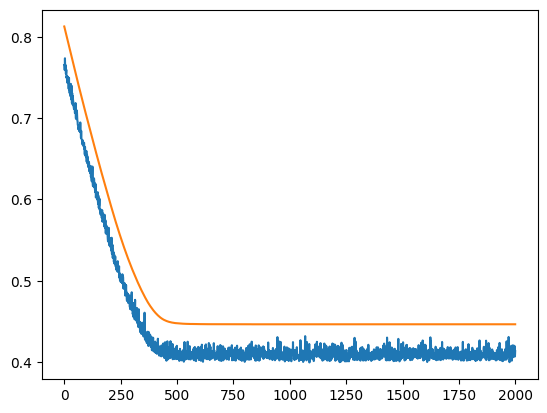

In [37]:
#No augmentation
#No keeping one sample together
#4 layers each 2 neurons, custom loss, equal weights
#PCA
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

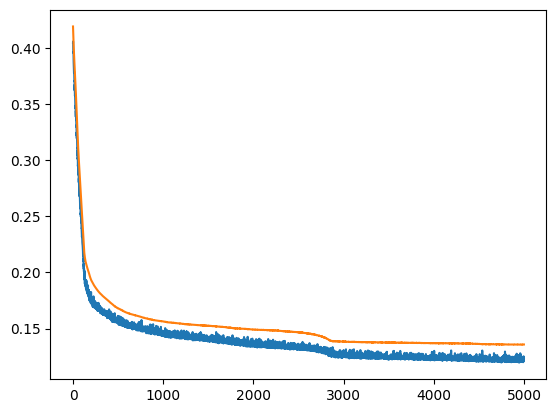

In [34]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

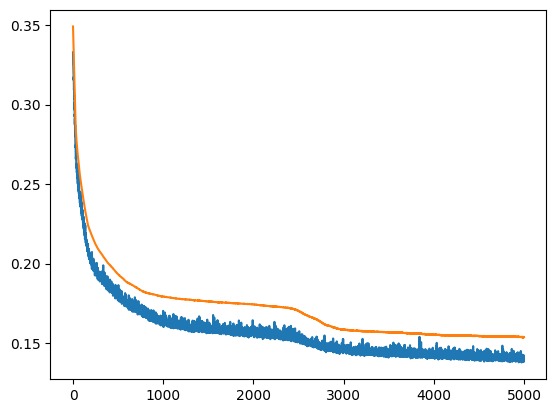

In [34]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights 1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

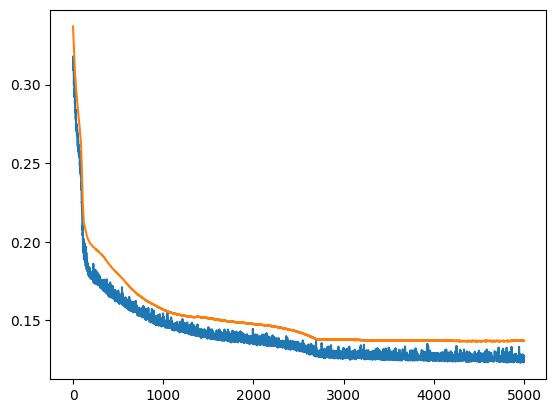

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

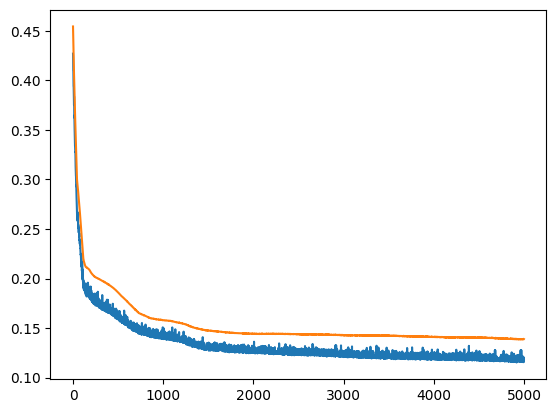

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

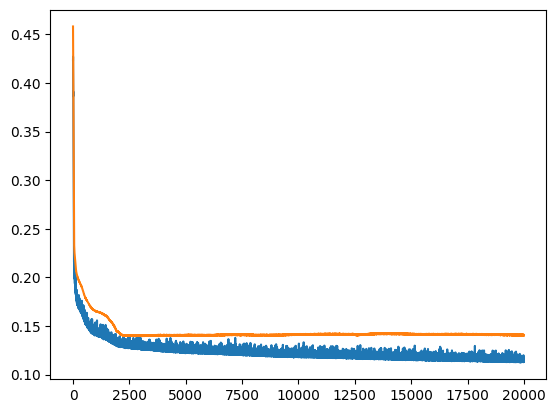

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

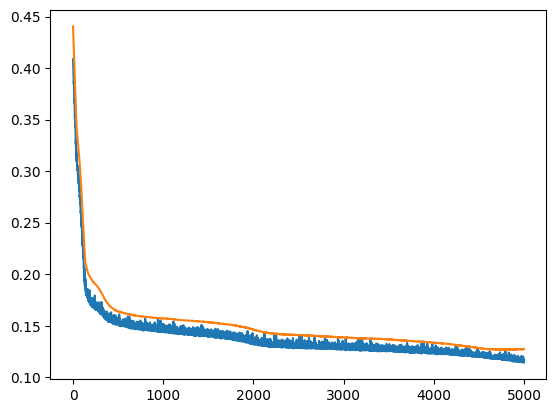

In [33]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#6 layers each 8 neurons, custom loss, weights [1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#6 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#8 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#6 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/3, 1/3, 1/18, 1/18, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/8, 1/8, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#Augmentation
#Keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#No keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#No augmentation
#keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#Augmentation
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#Augmentation
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 8 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#4 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

In [ ]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

In [ ]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Test set

In [48]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [49]:
lab

tensor([[-0.3710, -0.3650, -0.3842,  ...,  0.0842,  0.4576,  0.0389],
        [ 3.6760, -0.8705,  1.1306,  ..., -0.3379,  1.7154, -0.0089],
        [-0.2201,  0.0683,  1.1862,  ...,  0.3636,  0.0185,  0.1237],
        ...,
        [ 0.2612, -0.4831, -0.1683,  ..., -0.5150,  1.2934, -0.0685],
        [-0.7713, -0.2485, -0.4467,  ..., -0.1358, -0.0557,  0.0199],
        [-0.7638, -0.2187, -0.3628,  ...,  0.0088, -0.2235,  0.0483]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [50]:
out

tensor([[-0.6318, -0.1763, -0.3349,  ...,  0.0153, -0.0493,  0.0504],
        [ 0.0152, -0.0566,  0.2034,  ..., -0.1635,  0.0263,  0.0044],
        [-0.4217,  0.1372,  0.5867,  ...,  0.0407,  0.0359,  0.0695],
        ...,
        [ 0.4201, -0.2147,  0.4444,  ..., -0.4052, -0.0820,  0.0983],
        [-0.5330, -0.2542, -0.4278,  ..., -0.0647, -0.0726,  0.0451],
        [-0.6119, -0.1954, -0.3622,  ..., -0.0039, -0.0464,  0.0462]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [51]:
res

tensor([[2.6089e-01, 1.8874e-01, 4.9203e-02,  ..., 6.8910e-02, 5.0691e-01,
         1.1498e-02],
        [3.6608e+00, 8.1398e-01, 9.2724e-01,  ..., 1.7445e-01, 1.6891e+00,
         1.3279e-02],
        [2.0154e-01, 6.8921e-02, 5.9955e-01,  ..., 3.2283e-01, 1.7412e-02,
         5.4208e-02],
        ...,
        [1.5884e-01, 2.6846e-01, 6.1268e-01,  ..., 1.0977e-01, 1.3754e+00,
         1.6680e-01],
        [2.3829e-01, 5.7445e-03, 1.8957e-02,  ..., 7.1168e-02, 1.6863e-02,
         2.5225e-02],
        [1.5192e-01, 2.3359e-02, 5.8731e-04,  ..., 1.2668e-02, 1.7710e-01,
         2.1397e-03]], device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [52]:
torch.mean(res, axis=0) 

tensor([0.5340, 0.3980, 0.3910, 0.3109, 0.4032, 0.3260, 0.3572, 0.1419],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [53]:
torch.mean(res, axis=0)

tensor([0.5340, 0.3980, 0.3910, 0.3109, 0.4032, 0.3260, 0.3572, 0.1419],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [54]:
Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

SyntaxError: invalid syntax (4073561584.py, line 1)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [55]:
torch.mean(res)

tensor(0.3578, device='cuda:0', grad_fn=<MeanBackward0>)

In [56]:
torch.mean(res)

tensor(0.3578, device='cuda:0', grad_fn=<MeanBackward0>)

Below: some experiments, visualisations...

In [42]:
dim_nr = 5
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

In [43]:
#torch.max(out, axis=0)

(-0.1, 0.1)

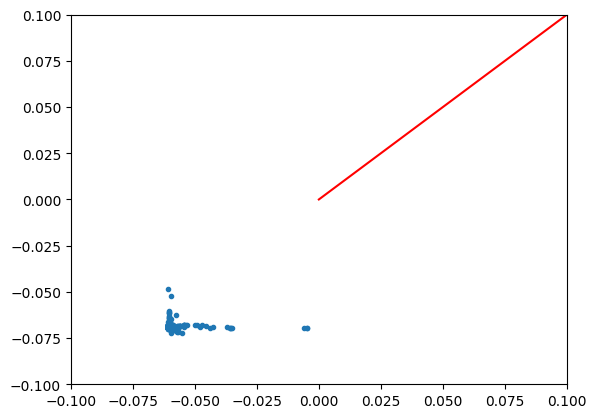

In [44]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [0,20],[0,20], 'red' )
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)

In [45]:
torch.mean(res, 0)

tensor([0.1679, 0.1206, 0.1253, 0.2893, 0.3142, 0.0687, 0.1075, 0.0544],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [46]:
mean_loss

0.15598308939224506

## Quality of prediction: closest points

In [57]:
model.eval()
outputs = model(X_test)

In [58]:
outputs.shape

torch.Size([474, 8])

In [59]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = pc_names_y
outputs_df.insert(0, 'Sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [60]:
closest_y = []
for i in range(outputs_df.shape[0]):
    idx_min = abs(outputs_df[pc_names_y].iloc[i] - mean_df[pc_names_y]).sum(1).idxmin()
    closest_y.append(int(mean_df.iloc[idx_min,:]['Sample_id']))

In [61]:
outputs_df['Closest_id_y'] = closest_y

In [62]:
outputs_df[outputs_df['Closest_id_y'] == outputs_df['Sample_id']].shape[0]

21

In [62]:
outputs_df.shape

(474, 4)

In [63]:
13/474

0.027426160337552744

In [42]:
elements_names = [el.split('_')[0] for el in inds_colnames]
elements_names = ['PC1', 'PC2']

In [43]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [44]:
train_val_data_normalized_df = pd.DataFrame(y_train.cpu())
train_val_data_normalized_df = pd.concat([train_val_data_normalized_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_data_normalized_df.columns = elements_names
train_val_data_normalized_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_data_normalized_df.reset_index(drop=True, inplace=True)

In [45]:
mean_df = train_val_data_normalized_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_data_normalized_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
# for name in elements_names:
#     mean_sd_df[name + '_sd'] = train_val_data_normalized_df.groupby('Sample_id')[name].transform(np.std)
#     mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_5496/1554198251.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_data_normalized_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_5496/1554198251.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_5496/1554198251.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [46]:
closest = []
for i in range(outputs_df.shape[0]):
    closest.append((abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin())

In [47]:
len(closest)

483

In [48]:
outputs_df['Closest'] = closest

In [49]:
outputs_df[outputs_df['Sample_id'] == outputs_df['Closest']].shape[0]

2

In [50]:
outputs_df

,Sample_id,PC1,PC2,Closest
0,35,-0.292795,-0.309985,1
1,62,-0.292795,-0.309985,1
2,120,-0.292795,-0.309985,1
3,19,-0.292795,-0.309985,1
4,71,-0.292795,-0.309985,1
...,...,...,...,...
478,56,-0.292795,-0.309985,1
479,112,-0.292795,-0.309985,1
480,25,-0.292795,-0.309985,1
481,78,-0.292795,-0.309985,1


## Quality of prediction: PCA + closest points

In [84]:
model.eval()
outputs = model(X_test)

In [85]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [86]:
outputs_np = outputs.cpu().detach().numpy()

In [87]:
y_train_val_normalized = np.concatenate([y_train.cpu(), y_val.cpu()])

In [88]:
from sklearn.decomposition import PCA

In [89]:
n_components = 2
pca = PCA(n_components=n_components)
y_train_val_normalized_pca = pca.fit_transform(y_train_val_normalized)

In [125]:
outputs_pca = pca.transform(outputs_np)
outputs_pca_df = pd.DataFrame(outputs_pca,
                          columns=['PC' + str(numb) for numb in range(1, n_components+1)])
outputs_pca_df.insert(0, 'Sample_id', test_order)
outputs_pca_df.reset_index(drop=True, inplace=True)

In [119]:
train_val_pca_df = pd.DataFrame(y_train_val_normalized_pca, 
                                columns=['PC' + str(numb) for numb in range(1, n_components+1)])
sample_ids = (pd.concat([train_order, val_order])).reset_index(drop=True)
train_val_pca_df['Sample_id'] = sample_ids

mean_df = train_val_pca_df[['Sample_id']]

for name in ['PC' + str(numb) for numb in range(1, n_components+1)]:
    mean_df[name] = train_val_pca_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_15170/2661011248.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_pca_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_15170/2661011248.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_15170/2661011248.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

In [164]:
closest = []
for i in range(outputs_pca_df.shape[0]):
    closest.append((abs(outputs_pca_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin())

In [165]:
len(closest)

483

In [166]:
outputs_pca_df['Closest'] = closest

In [167]:
outputs_pca_df[outputs_df['Sample_id'] == outputs_pca_df['Closest']].shape[0]

19

In [132]:
mean_df

,Sample_id,PC1,PC2
0,0,-0.109696,-0.125674
1,1,-0.269590,-0.316761
2,2,-0.160324,-0.368295
3,3,0.022731,-0.288791
4,4,-0.255851,-0.344971
...,...,...,...
156,156,-0.334599,-0.321347
157,157,-0.464163,-0.491251
158,158,15.115793,-2.703488
159,159,-0.427799,-0.505952


In [135]:
train_val_pca_df

,PC1,PC2,Sample_id
0,-0.353923,-0.383893,94
1,-0.017077,-0.011902,63
2,-0.398686,-0.139170,28
3,7.399920,6.234650,59
4,-0.131514,-0.243546,71
...,...,...,...
1927,-0.004640,-0.009605,40
1928,0.725637,0.759928,65
1929,-0.201412,-0.235588,136
1930,0.907938,0.958195,65


In [138]:
import matplotlib.colors as mcolors

In [168]:
num_colors = len(train_val_pca_df['Sample_id'].unique())
cm = plt.get_cmap('gist_rainbow')
colors_list = [cm(1.*i/num_colors) for i in range(num_colors)]

colors_vector = [list(colors_list[el][0:3]) for el in train_val_pca_df['Sample_id']]
colors_vector_output = [list(colors_list[el][0:3]) for el in outputs_pca_df['Sample_id']]

ValueError: [[0.0, 1.0, 0.9909340080118073], [0.04239533651298355, 1.0, 0.0], [1.0, 0.7705352411234765, 0.0], [0.19077901430842603, 1.0, 0.0], [0.0, 1.0, 0.2108370229812356], [0.0, 1.0, 0.527092557453089], [0.38155802861685206, 1.0, 0.0], [0.8479067302596713, 1.0, 0.0], [0.6995230524642289, 1.0, 0.0], [0.0, 0.13533674339300916, 1.0], [0.0, 1.0, 0.04216740459624712], [0.31223358908780924, 0.0, 1.0], [1.0, 0.7281399046104929, 0.0], [0.0, 0.5402813299232734, 1.0], [0.0, 0.4763427109974422, 1.0], [1.0, 0.8977212506624273, 0.0], [0.3179650238473768, 1.0, 0.0], [1.0, 0.0, 0.013594771241830061], [0.0, 0.796035805626598, 1.0], [0.35485933503836337, 0.0, 1.0], [1.0, 0.09220985691573928, 0.0], [0.0, 0.9452259164535375, 1.0], [0.0, 0.7107843137254899, 1.0], [0.0, 0.9026001705029834, 1.0], [0.3179650238473768, 1.0, 0.0], [1.0, 0.5585585585585586, 0.0], [1.0, 0.0, 0.07633986928104575], [0.0, 1.0, 0.46384145055871834], [0.6571277159512453, 1.0, 0.0], [1.0, 0.5373608903020667, 0.0], [0.0, 0.902600170

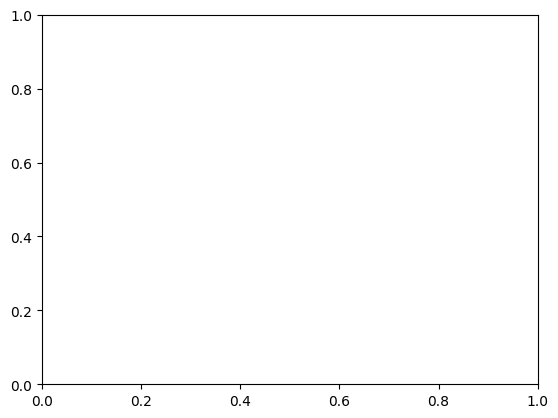

In [160]:
plt.plot(train_val_pca_df['PC1'], train_val_pca_df['PC2'], '.', c=colors_vector)

In [176]:
%matplotlib notebook

<IPython.core.display.Javascript object>


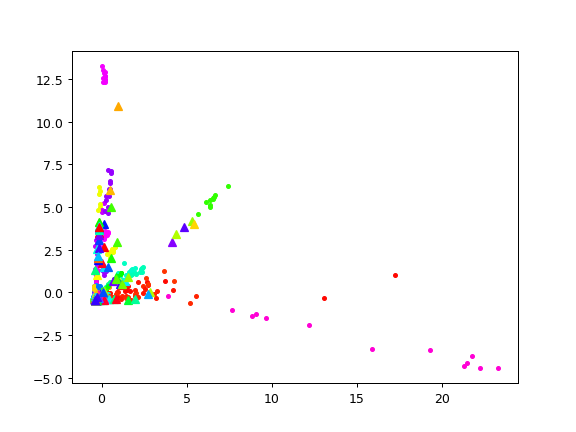

/tmp/ipykernel_15170/3367273864.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(outputs_pca_df['PC1'][i], outputs_pca_df['PC2'][i], '.',


In [178]:
for i in range(train_val_pca_df.shape[0]):
    plt.plot(train_val_pca_df['PC1'][i], train_val_pca_df['PC2'][i], '.', c=colors_vector[i])
    
for i in range(outputs_pca_df.shape[0]):
    plt.plot(outputs_pca_df['PC1'][i], outputs_pca_df['PC2'][i], '.',
             c=colors_vector[i], marker='^')

## Quality of prediction: confidence intervals

In [45]:
model.eval()
outputs = model(X_test)

In [46]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [47]:
all_data_normalized_df = pd.DataFrame(y_train.cpu())
all_data_normalized_df = pd.concat([all_data_normalized_df, 
                                    pd.DataFrame(y_val.cpu()), 
                                    pd.DataFrame(y_test.cpu())])
all_data_normalized_df.columns = elements_names
all_data_normalized_df.insert(0, 'Sample_id', pd.concat([train_order, val_order, test_order]))
all_data_normalized_df.reset_index(drop=True, inplace=True)

In [49]:
min_max_df = all_data_normalized_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_normalized_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_normalized_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
min_df = min_max_df.iloc[:,1+len(elements_names):]

/tmp/ipykernel_7545/3485105690.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_normalized_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_7545/3485105690.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7545/3485105690.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [69]:
mean_sd_df = all_data_normalized_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_normalized_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_normalized_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)

/tmp/ipykernel_7545/104805948.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_normalized_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_7545/104805948.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_7545/104805948.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

In [50]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > np.array(min_df.iloc[sample_id,:])
    
    less_than_max = test_example.cpu().detach().numpy() < np.array(max_df.iloc[sample_id,:])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [73]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > np.array(lower_bound_df.iloc[sample_id,:])
    
    less = test_example.cpu().detach().numpy() < np.array(upper_bound_df.iloc[sample_id,:])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [79]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

In [80]:
np.array(sd_res_list).mean()

0.6529503105590062

In [78]:
np.array(sd_res_list).mean(0)

array([0.63768116, 0.61283644, 0.77432712, 0.32919255, 0.67080745,
       0.99792961, 0.25879917, 0.94202899])

In [51]:
np.array(min_max_res_list).mean(0)

array([0.54658385, 0.50517598, 0.71635611, 0.28778468, 0.35196687,
       0.95238095, 0.21325052, 0.78467909])

In [52]:
np.array(min_max_res_list).mean()

0.5447722567287785

In [62]:
np.array(min_max_res_list).mean(0)

array([0.4699793 , 0.52380952, 0.8757764 , 0.28985507, 0.28778468,
       0.95859213, 0.20910973, 0.74741201])

In [73]:
%matplotlib notebook

In [102]:
outputs.shape

torch.Size([483, 8])

In [86]:
%matplotlib notebook

<IPython.core.display.Javascript object>


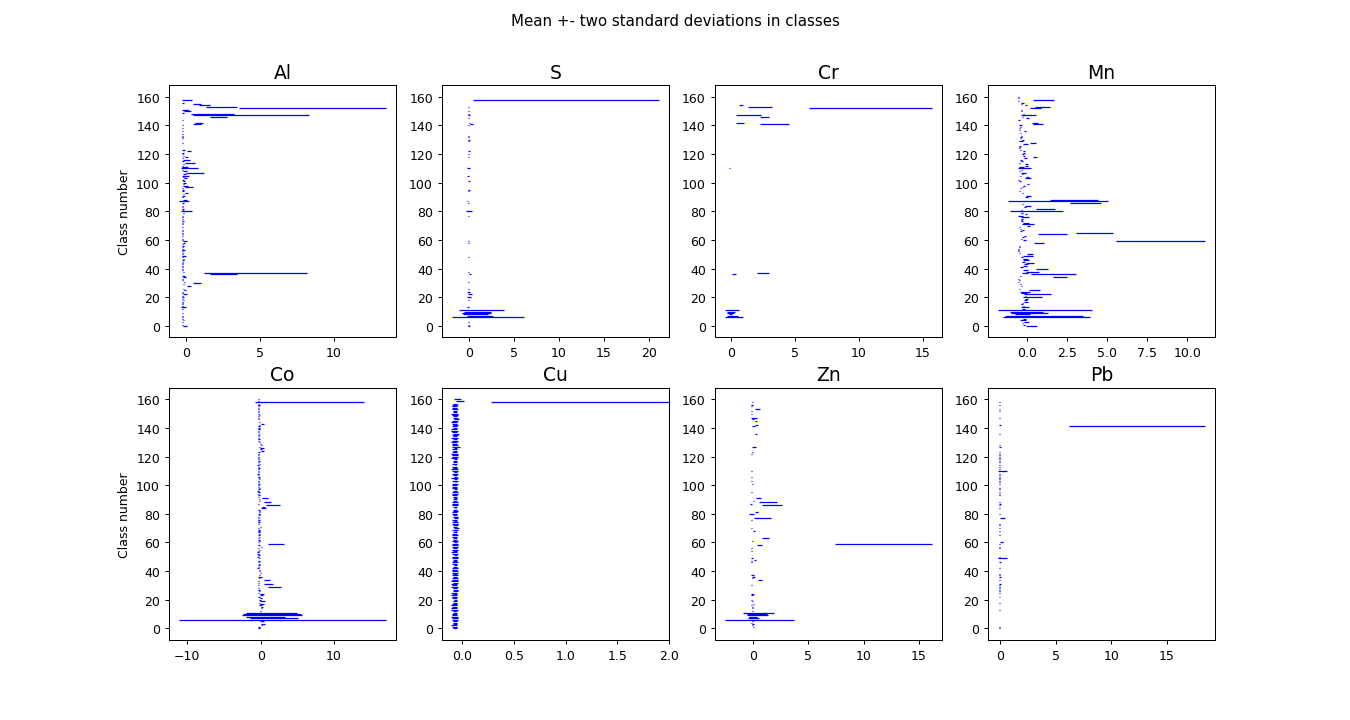

In [111]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

<IPython.core.display.Javascript object>


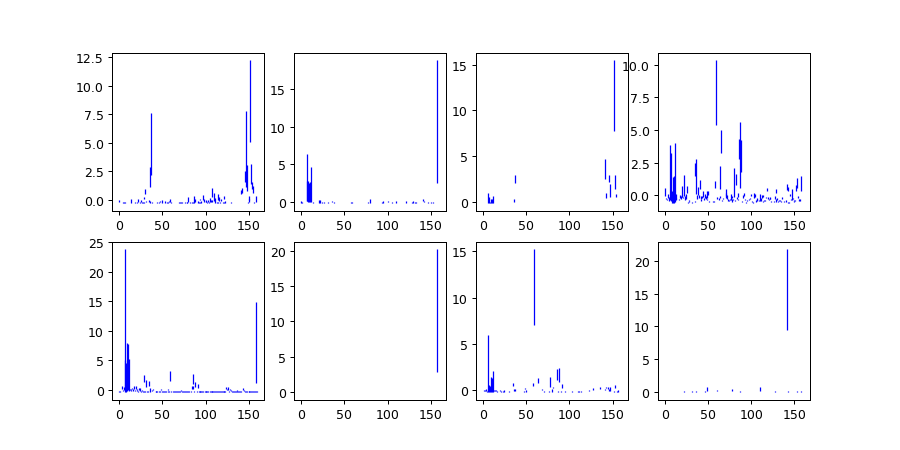

In [104]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

<IPython.core.display.Javascript object>


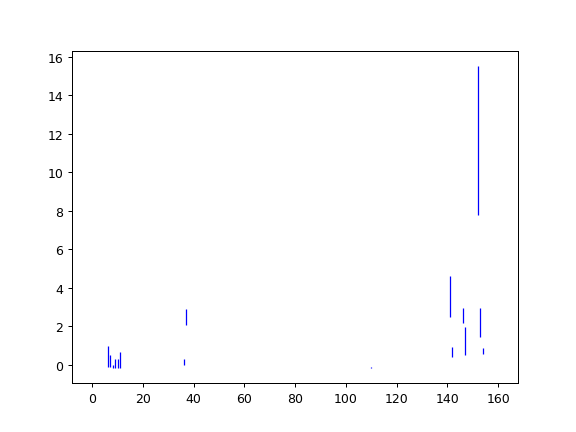

In [108]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

In [ ]:
inside_min_max_interval = torch.cat([res.unsqueeze(0) for res in res_list])

In [ ]:
(inside_min_max_interval*1.0).mean(axis=0)

In [48]:
(inside_min_max_interval*1.0).mean(axis=0) #best weights: 1/2, 1/4, 1/8, 1/40, ...

tensor([0.2854, 0.3729, 0.0542, 0.0729, 0.0625, 0.0500, 0.0125, 0.2188],
       device='cuda:0')

In [44]:
from_sample.mean(axis=0)

tensor([ 5.0448, -0.1901,  5.1446, -0.1243, -0.5578,  0.0341, -0.1956,  0.1323],
       device='cuda:0')

In [46]:
from_sample.std(axis=0)

tensor([0.7062, 0.0081, 0.2986, 0.0153, 0.0049, 0.0180, 0.0018, 0.0793],
       device='cuda:0')

(array([2., 1., 0., 4., 3., 2., 0., 0., 2., 1.]),
 array([0.0093034 , 0.03666412, 0.06402484, 0.09138557, 0.11874629,
        0.146107  , 0.17346773, 0.20082845, 0.22818917, 0.25554991,
        0.28291062]),
 <BarContainer object of 10 artists>)

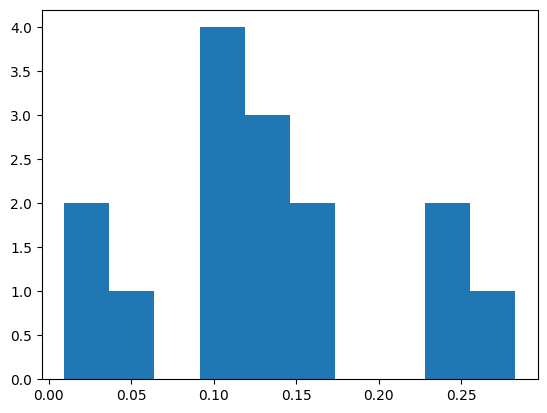

In [67]:
plt.hist(np.array(from_sample[:,7].cpu()))

## Interpretability

...